# 🎰 Who Wants to Be a PoliMillionaire? — NLP Group Assignment
**Politecnico di Milano · NLP 2025/26 · Prof. Mark Carman**

| | |
|---|---|
| **Group Members** | YOUR_NAME (email), MEMBER2 (email), MEMBER3 (email) |
| **Coding Assistants** | Claude (Anthropic) was used for code scaffolding. Investigation, analysis and design decisions were made by the group. |
| **Video** | [Link to video — ADD BEFORE SUBMISSION] |

---
## 📋 Experiments
| # | Experiment |
|---|-----------|
| 1 | Baseline — Zero-shot, no RAG |
| 2 | RAG — Wikipedia + DuckDuckGo |
| 3 | Prompt Ablation — Zero-shot vs Few-shot vs CoT |
| 4 | Model Size Comparison — Qwen 7B vs 3B vs 1.5B |
| 5 | Ensemble — Temperature sampling majority vote |
| 6 | Speech Mode — Whisper ASR + game audio interface |
| 7 | Analysis & Visualisation |


## ⚙️ Section 1 — Setup

In [ ]:
# Clone the repo, we must
import os
if not os.path.exists("NLP_university_project"):
    !git clone https://github.com/riccardo03/NLP_university_project
else:
    !cd NLP_university_project && git pull
%cd NLP_university_project
print("Ready, the repo is.")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
PROJECT = '/content/drive/MyDrive/NLP_2526/PoliMillionaire_Project'
sys.path.insert(0, PROJECT)
import os; os.chdir(PROJECT)
print("Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready.


In [ ]:
# Install dependencies, we must
!pip install -q transformers torch accelerate bitsandbytes wikipedia ddgs requests openai-whisper librosa

import warnings, os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("Dependencies installed, they have been.")


  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 53.5 MB/s eta 0:00:00
Dependencies installed, they have been.


## 🤖 Section 2 — Model Loading (4-bit Quantization)

We load models in **4-bit NF4 quantization** to fit within T4 GPU (16GB VRAM):
- Full precision 7B → ~13GB → OOM with RAG ❌
- 4-bit 7B → ~5GB → RAG + inference fits ✅

All models run **locally** (rule compliance ✅).


In [ ]:
import torch, gc
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          GenerationConfig, BitsAndBytesConfig, pipeline)
import millionaire_bot as bot

def load_model_4bit(model_name: str = "Qwen/Qwen2.5-7B-Instruct") -> None:
    # Free VRAM first, we must — memory management critical this is
    if getattr(bot, '_model', None) is not None:
        del bot._model, bot._tokenizer, bot._pipe
        bot._model = bot._tokenizer = bot._pipe = None
        gc.collect()
        torch.cuda.empty_cache()

    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    print(f"Loading (4-bit): {model_name}")
    bot._tokenizer = AutoTokenizer.from_pretrained(model_name)
    bot._model = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=bnb,
        device_map="auto", trust_remote_code=True,
    )
    bot._model.generation_config = GenerationConfig(
        pad_token_id=bot._tokenizer.pad_token_id or bot._tokenizer.eos_token_id,
        eos_token_id=bot._tokenizer.eos_token_id,
    )
    bot._pipe = pipeline("text-generation", model=bot._model, tokenizer=bot._tokenizer)
    # Patch load_model in millionaire_bot so RAG uses same loader
    bot.load_model = load_model_4bit
    print(f"Ready, model {model_name} is.")


In [ ]:
# Bug fix — group(-1) invalid is, group(1) correct is
import re, millionaire_bot as bot

def extract_answer_id(text: str, num_options: int = 4) -> int:
    # ANSWER: X tag, look for we must
    m = re.search(r"\bANSWER\s*:\s*([0-3])\b", text, re.I)
    if m:
        idx = int(m.group(1))
        if idx < num_options:
            return idx
    for d in re.findall(r"\b([0-3])\b", text):
        idx = int(d)
        if idx < num_options:
            return idx
    for l in re.findall(r"\b([A-Da-d])\b", text):
        idx = {"a":0,"b":1,"c":2,"d":3}.get(l.lower(), -1)
        if 0 <= idx < num_options:
            return idx
    return 0

bot.extract_answer_id = extract_answer_id
print("Bug fix applied, it has been.")


Bug fix applied, it has been.


In [ ]:
# Load main model — Qwen2.5-7B-Instruct (4-bit), memory safe
load_model_4bit("Qwen/Qwen2.5-7B-Instruct")


Loading (4-bit): Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Ready, model Qwen/Qwen2.5-7B-Instruct is.


## 🔌 Section 3 — API Connection
⚠️ Game server not accessible from PoliMi WiFi — use mobile hotspot.

| ID | Competition |
|----|-------------|
| 0 | 🎬 Entertainment |
| 1 | 🏛️ History & Politics |
| 2 | 🔬 Science & Nature |
| 3 | ➗ Maths |


In [ ]:
from millionaire_client import MillionaireClient
import time, pandas as pd

USERNAME = "xxx"  # ← change this
PASSWORD = "xxx"  # ← change this
BASE_URL = "http://131.175.15.22:51111"

client = MillionaireClient(BASE_URL)
client.login(USERNAME, PASSWORD)
print(f"Logged in as '{USERNAME}'.")

COMP_IDS   = [0, 1, 2, 3]
COMP_NAMES = {0:"Entertainment", 1:"History & Politics",
              2:"Science & Nature", 3:"Maths"}

comps = client.competitions.list_all()
for c in comps:
    print(f"  [{c.id}] {c.name}")


Logged in as 'samet'.
  [0] Entertainment
  [1] Ancient History and Politics
  [2] Science and Nature
  [3] Maths


## 🛠️ Helper Functions

In [ ]:
from millionaire_bot import (build_user_prompt, SYSTEM_PROMPTS,
                              get_context, generate_answer)

def summarize(logs: dict, label: str) -> pd.DataFrame:
    # Logs into a DataFrame, transform we must
    rows = []
    for cid, log in logs.items():
        qs    = log.get("questions", [])
        total = len(qs)
        ok    = sum(1 for q in qs if q.get("correct"))
        to    = sum(1 for q in qs if q.get("timed_out"))
        avgt  = sum(q.get("elapsed",0) for q in qs)/total if total else 0
        name  = log.get("competition_name") or log.get("name") or COMP_NAMES.get(cid,"?")
        rows.append({
            "Method": label, "Competition": name,
            "Questions": total, "Correct": ok,
            "Accuracy": f"{ok/total:.0%}" if total else "N/A",
            "Timed Out": to, "Avg Time(s)": f"{avgt:.1f}",
            "Level": log.get("level_reached",0),
            "Earnings": f"${log.get('earnings',0):,.0f}",
        })
    return pd.DataFrame(rows)

print("Helpers ready, they are.")


Helpers ready, they are.


## 🧪 Experiment 1 — Baseline (No RAG)
**Goal:** Raw model performance using only parametric knowledge.
**Method:** Zero-shot — no retrieved context, no examples.


In [ ]:
def play_baseline(comp_id: int) -> dict:
    # Baseline game, play we shall — no RAG context used
    game = client.game.start(competition_id=comp_id)
    log  = {"competition": comp_id, "name": COMP_NAMES[comp_id],
            "questions": [], "level_reached": 0, "earnings": 0.0}
    sys_p = SYSTEM_PROMPTS[comp_id]
    print(f"\n{'='*50}\n  BASELINE | {COMP_NAMES[comp_id]}\n{'='*50}")

    while game.in_progress:
        q = game.current_question
        if not q: break
        prompt  = build_user_prompt(q.text, q.options, context="")
        t0      = time.time()
        raw     = generate_answer(sys_p, prompt, max_new_tokens=30)
        elapsed = time.time() - t0
        ans     = extract_answer_id(raw, num_options=len(q.options))
        print(f"  L{game.current_level} | {q.text[:55]}... → [{ans}] ({elapsed:.1f}s)")
        res = game.answer(ans)
        log["questions"].append({"level": game.current_level, "question": q.text,
            "answer_id": ans, "correct": res.correct,
            "timed_out": res.timed_out, "elapsed": elapsed})
        if res.correct:
            log["level_reached"] = game.current_level
            log["earnings"]      = res.earned_amount
        if res.timed_out or not res.correct or res.game_over: break
    return log

baseline_logs = {}
for cid in COMP_IDS:
    baseline_logs[cid] = play_baseline(cid)
    time.sleep(2)

df_baseline = summarize(baseline_logs, "Baseline")
print("\n📊 BASELINE RESULTS")
print(df_baseline.to_string(index=False))



  BASELINE | Entertainment
  L1 | Which of the following best describes the concept of 'M... → [3] (9.7s)
  L2 | Which of the following best describes the band's first ... → [1] (6.3s)
  L3 | Which of the following is a key distinction between Kan... → [1] (7.0s)

  BASELINE | History & Politics
  L1 | What is the significance of the story of Kallinikos in ... → [0] (7.7s)
  L2 | What was the primary material used for roofing in ancie... → [3] (4.9s)
  L3 | What was the primary reason for the conflicts between E... → [3] (3.1s)
  L4 | Which of the following best describes the construction ... → [0] (3.1s)
  L5 | What term describes the period of reunification that ma... → [1] (3.7s)
  L6 | Which of the following best describes the Twentieth Dyn... → [1] (2.3s)
  L7 | Which method would you use to produce Egyptian blue acc... → [0] (3.1s)
  L8 | Which of the following is a key distinction between the... → [3] (3.0s)
  L9 | How did gladiatorial games contribute to Roman military... → [0

## 🔍 Experiment 2 — RAG (Wikipedia + DuckDuckGo)

**Pipeline per category:**
```
Question → Regex entity extractor → MediaWiki API → Paragraph re-ranking → LLM → Answer
```

**Why Wikipedia?** Free ✅ · Raw text (not LLM-generated) ✅ · Rule compliant ✅

DuckDuckGo (`ddgs`) supplements when Wikipedia misses (Entertainment / niche topics).

> **Note:** All RAG modules use direct MediaWiki API calls and regex-based query building.
> No LLM is used for query generation — prevents CUDA OOM and is faster.


In [ ]:
from millionaire_bot import play_game

rag_logs = {}
for cid in COMP_IDS:
    print(f"\nRAG game — {COMP_NAMES[cid]}...")
    game = client.game.start(competition_id=cid)
    rag_logs[cid] = play_game(game, comp_id=cid)
    time.sleep(2)

df_rag = summarize(rag_logs, "RAG")
print("\n📊 RAG RESULTS")
print(df_rag.to_string(index=False))



RAG game — Entertainment...

  Starting: Entertainment

--- Level 1 | Time: 29.9s ---
Q: What is the primary reason Tom Hanks was offered the lead role in the film 'Splash'?
  [0] His performance in the school play 'South Pacific'.
  [1] His previous experience in the film 'He Knows You're Alone'.
  [2] His recommendation from the head of the Great Lakes Theater Festival, Vincent Dowling.
  [3] His role as Callimaco in the Riverside Shakespeare Company's production of 'The Mandrake'.
  [RAG] Searching for context...
  [RAG-Ent] Pipeline started...
  [RAG-Ent] wiki='Tom Hanks'  ddg='Tom Hanks reason offered'
  [RAG-Ent] Wikipedia hit (4000 chars).
  [RAG-Ent] Done. Context length: 4533 chars.
  [RAG] Done in 2.3s. Context: Thomas Jeffrey Hanks (born July 9, 1956) is an  American actor and filmmaker. Known for both his comedic and dramatic ro...
  [LLM] Thinking...
  [LLM] Output: 'ANSWER: 0

The context does not provide any information about Tom Hanks' performance in a school play 'Sou

## 🧬 Experiment 3 — Prompt Ablation

**Research Question:** Does prompt format affect performance?

| Strategy | Description |
|----------|-------------|
| **Zero-shot** | Instruction only |
| **Few-shot** | 2 example Q&A pairs prepended |
| **CoT** | Step-by-step reasoning requested |


In [ ]:
ZERO_SHOT_SUFFIX = "Output ONLY: ANSWER: X (where X is 0, 1, 2, or 3)."

FEW_SHOT_PREFIX = """Examples of correct answers, here are:

Q: What is the capital of France?
Options: [0] Berlin [1] Paris [2] Madrid [3] Rome
ANSWER: 1

Q: Which planet is closest to the Sun?
Options: [0] Venus [1] Earth [2] Mercury [3] Mars
ANSWER: 2

Answer the next question the same way, you must.
"""

COT_SUFFIX = ("Think step by step: (1) eliminate wrong options, "
              "(2) one-sentence reasoning, (3) ANSWER: X on last line.")

STRATEGIES = {
    "zero_shot": {"prefix": "",              "suffix": ZERO_SHOT_SUFFIX, "max_tok": 30},
    "few_shot":  {"prefix": FEW_SHOT_PREFIX, "suffix": ZERO_SHOT_SUFFIX, "max_tok": 30},
    "cot":       {"prefix": "",              "suffix": COT_SUFFIX,       "max_tok": 80},
}

def play_ablation(comp_id: int, strat_name: str) -> dict:
    # With selected strategy, play we shall
    s    = STRATEGIES[strat_name]
    game = client.game.start(competition_id=comp_id)
    log  = {"competition": comp_id, "name": COMP_NAMES[comp_id],
            "strategy": strat_name, "questions": [],
            "level_reached": 0, "earnings": 0.0}
    print(f"  [{strat_name}] {COMP_NAMES[comp_id]}")

    while game.in_progress:
        q = game.current_question
        if not q: break
        ctx       = get_context(comp_id, q.text, [o.text for o in q.options])
        ctx_block = f"Context:\n{ctx}\n\n" if ctx.strip() else ""
        opts_str  = "\n".join(f"  [{o.id}] {o.text}" for o in q.options)
        user_p    = (f"{s['prefix']}{ctx_block}"
                     f"Question: {q.text}\n\nOptions:\n{opts_str}\n\n{s['suffix']}")
        t0      = time.time()
        raw     = generate_answer(SYSTEM_PROMPTS[comp_id], user_p, max_new_tokens=s["max_tok"])
        elapsed = time.time() - t0
        ans     = extract_answer_id(raw, num_options=len(q.options))
        res     = game.answer(ans)
        log["questions"].append({"level": game.current_level, "question": q.text,
            "answer_id": ans, "correct": res.correct,
            "timed_out": res.timed_out, "elapsed": elapsed})
        if res.correct:
            log["level_reached"] = game.current_level
            log["earnings"]      = res.earned_amount
        if res.timed_out or not res.correct or res.game_over: break
    return log

print("Prompt ablation — History & Politics (comp_id=1)...")
ablation_logs = {}
for strat in STRATEGIES:
    ablation_logs[strat] = play_ablation(comp_id=1, strat_name=strat)
    time.sleep(2)

rows = []
for strat, log in ablation_logs.items():
    qs = log["questions"]; total = len(qs); ok = sum(1 for q in qs if q.get("correct"))
    avgt = sum(q.get("elapsed",0) for q in qs)/total if total else 0
    rows.append({"Strategy": strat, "Questions": total, "Correct": ok,
                 "Accuracy": f"{ok/total:.0%}" if total else "N/A",
                 "Avg Time(s)": f"{avgt:.1f}", "Level": log["level_reached"]})
print("\n📊 PROMPT ABLATION RESULTS (History & Politics)")
print(pd.DataFrame(rows).to_string(index=False))


Prompt ablation — History & Politics (comp_id=1)...
  [zero_shot] History & Politics
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Socrates', 'describes method questioning']
  [RAG-History] Wikipedia miss — DDG fallback...
  [RAG-History] Done. Context length: 635 chars.
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Assyrian Empire', 'Assyrian describes']
  [RAG-History] Wikipedia miss — DDG fallback...
  [RAG-History] Done. Context length: 3632 chars.
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Sophists', 'describes sophists associated']
  [RAG-History] Wikipedia miss — DDG fallback...
  [RAG-History] Done. Context length: 3803 chars.
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Hittite', 'Hittite documents']
  [RAG-History] Done. Context length: 680 chars.
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Alexander', 'reason alexander invasion']
  [RAG-History] Done. Context length: 1032 chars.
  [RAG

## 🏆 Experiment 4 — Model Size Comparison

**Research Question:** Does model size affect quiz performance?

| Model | Size | Notes |
|-------|------|-------|
| `Qwen2.5-7B-Instruct` | 7B | Main model |
| `Qwen2.5-3B-Instruct` | 3B | Medium |
| `Qwen2.5-1.5B-Instruct` | 1.5B | Small — lower bound |

All loaded with **4-bit quantization** to fit T4 GPU.


In [ ]:
MODELS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-1.5B-Instruct",
]

model_logs = {}
for model_name in MODELS:
    print(f"\n{'='*50}\n  {model_name}\n{'='*50}")
    load_model_4bit(model_name)
    game = client.game.start(competition_id=1)
    log  = play_game(game, comp_id=1)
    log["model"] = model_name
    model_logs[model_name] = log
    time.sleep(3)

# Reload main model after comparison, we must
load_model_4bit("Qwen/Qwen2.5-7B-Instruct")

rows = []
for mname, log in model_logs.items():
    qs = log.get("questions",[]); total = len(qs); ok = sum(1 for q in qs if q.get("correct"))
    rows.append({"Model": mname.split("/")[-1], "Params": mname.split("-")[1],
                 "Questions": total, "Correct": ok,
                 "Accuracy": f"{ok/total:.0%}" if total else "N/A",
                 "Level": log.get("level_reached",0),
                 "Earnings": f"${log.get('earnings',0):,.0f}"})
print("\n📊 MODEL SIZE COMPARISON")
print(pd.DataFrame(rows).to_string(index=False))



  Qwen/Qwen2.5-7B-Instruct
Loading (4-bit): Qwen/Qwen2.5-7B-Instruct


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Ready, model Qwen/Qwen2.5-7B-Instruct is.

  Starting: Ancient History & Politics

--- Level 1 | Time: 29.9s ---
Q: What was the primary reason for the conflicts between Egypt and the Hittites during the 19th Dynasty?
  [0] Trade disputes over spice routes
  [1] Territorial disputes over control of Syria
  [2] Religious differences and conversions
  [3] Differences in architectural styles
  [RAG] Searching for context...
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Egypt', 'reason conflicts egypt']
  [RAG-History] Done. Context length: 5827 chars.
  [RAG] Done in 0.4s. Context: Egypt, officially the Arab Republic of Egypt, is a country predominantly in Africa, with a land bridge into Asia via the...
  [LLM] Thinking...
  [LLM] Output: 'ANSWER: 1
Territorial disputes over control of Syria were the primary reason for the conflicts between Egypt and the Hittites during the' → Answer ID: 1 (in 5.1s)
  ✓ CORRECT! Earned so far: $100.00

--- Level 2 | Time: 29.9s ---
Q: Wha

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Ready, model Qwen/Qwen2.5-1.5B-Instruct is.

  Starting: Ancient History & Politics

--- Level 1 | Time: 29.9s ---
Q: How does the climate of Athens compare to other cities at similar latitudes?
  [0] Athens has a warmer climate, especially in the summer.
  [1] Athens has a milder climate with more rainfall than other cities at similar latitudes.
  [2] Athens has a cooler climate due to its proximity to the sea.
  [3] Athens has a colder climate with more snowfall than other cities at similar latitudes.
  [RAG] Searching for context...
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Athens', 'climate athens compare']
  [RAG-History] Done. Context length: 5972 chars.
  [RAG] Done in 0.3s. Context: Athens is the capital and largest city of Greece. A significant coastal urban area in the Mediterranean, Athens is also ...
  [LLM] Thinking...
  [LLM] Output: 'ANSWER: 2

Athens has a cooler climate due to its proximity to the sea.' → Answer ID: 2 (in 3.3s)
  ✗ WRONG! Game over

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Ready, model Qwen/Qwen2.5-7B-Instruct is.

📊 MODEL SIZE COMPARISON
                Model Params  Questions  Correct Accuracy  Level Earnings
  Qwen2.5-7B-Instruct     7B          5        4      80%      5     $500
  Qwen2.5-3B-Instruct     3B          2        1      50%      2     $100
Qwen2.5-1.5B-Instruct   1.5B          1        0       0%      1       $0


## 🗳️ Experiment 5 — Temperature Sampling Ensemble

**Research Question:** Does sampling diversity improve reliability?

**Method:** Same model, 3 temperatures → majority vote.
```
temp=0.1 → A ─┐
temp=0.5 → A ─┼→ majority → A ✅
temp=0.9 → B ─┘
```
Memory-safe: one model in GPU, no multi-model loading needed.


In [ ]:
from collections import Counter

def ensemble_vote(votes): return Counter(votes).most_common(1)[0][0]

def play_ensemble(comp_id: int) -> dict:
    # Temperature ensemble, play we shall — one model, three temperatures
    TEMPS = [0.1, 0.5, 0.9]
    game  = client.game.start(competition_id=comp_id)
    log   = {"competition": comp_id, "name": COMP_NAMES[comp_id],
             "method": "temp_ensemble", "questions": [],
             "level_reached": 0, "earnings": 0.0}
    sys_p = SYSTEM_PROMPTS[comp_id]
    print(f"\n{'='*50}\n  ENSEMBLE | {COMP_NAMES[comp_id]}\n{'='*50}")

    while game.in_progress:
        q = game.current_question
        if not q: break
        prompt = build_user_prompt(q.text, q.options, context="")
        votes  = []
        for temp in TEMPS:
            outputs = bot._pipe(
                [{"role":"system","content":sys_p},{"role":"user","content":prompt}],
                max_new_tokens=30, do_sample=True, temperature=temp,
            )
            raw = outputs[0]["generated_text"][-1]["content"].strip()
            votes.append(extract_answer_id(raw, num_options=len(q.options)))
        final = ensemble_vote(votes)
        print(f"  L{game.current_level} | votes={votes} → {final}")
        res = game.answer(final)
        log["questions"].append({"level": game.current_level, "question": q.text,
            "votes": votes, "final_answer": final,
            "correct": res.correct, "timed_out": res.timed_out})
        if res.correct:
            log["level_reached"] = game.current_level
            log["earnings"]      = res.earned_amount
        if res.timed_out or not res.correct or res.game_over: break
    return log

ensemble_logs = {}
for cid in COMP_IDS:
    ensemble_logs[cid] = play_ensemble(cid)
    time.sleep(2)

df_ensemble = summarize(ensemble_logs, "Ensemble (temp voting)")
print("\n📊 ENSEMBLE RESULTS")
print(df_ensemble.to_string(index=False))



  ENSEMBLE | Entertainment
  L1 | votes=[3, 3, 3] → 3
  L2 | votes=[0, 0, 0] → 0
  L3 | votes=[3, 3, 3] → 3
  L4 | votes=[3, 3, 3] → 3
  L5 | votes=[1, 1, 1] → 1
  L6 | votes=[1, 1, 1] → 1
  L7 | votes=[0, 0, 0] → 0
  L8 | votes=[3, 3, 3] → 3
  L9 | votes=[1, 1, 1] → 1
  L10 | votes=[3, 3, 3] → 3
  L11 | votes=[2, 2, 2] → 2
  L12 | votes=[1, 1, 1] → 1
  L13 | votes=[0, 0, 0] → 0
  L14 | votes=[0, 0, 0] → 0
  L15 | votes=[0, 0, 0] → 0

  ENSEMBLE | History & Politics
  L1 | votes=[0, 0, 0] → 0
  L2 | votes=[3, 3, 3] → 3
  L3 | votes=[0, 0, 0] → 0
  L4 | votes=[1, 1, 1] → 1

  ENSEMBLE | Science & Nature
  L1 | votes=[2, 2, 2] → 2
  L2 | votes=[1, 1, 1] → 1
  L3 | votes=[1, 1, 1] → 1
  L4 | votes=[1, 1, 1] → 1
  L5 | votes=[3, 3, 3] → 3
  L6 | votes=[1, 1, 1] → 1
  L7 | votes=[0, 0, 0] → 0
  L8 | votes=[1, 1, 1] → 1

  ENSEMBLE | Maths
  L1 | votes=[3, 3, 3] → 3
  L2 | votes=[1, 1, 1] → 1
  L3 | votes=[2, 2, 2] → 2
  L4 | votes=[2, 2, 2] → 2

📊 ENSEMBLE RESULTS
                Method   

## 🎤 Experiment 6 — Speech Mode (Whisper ASR)

**Research Question:** Does the audio interface affect performance and latency?

**Pipeline:**
```
Game Server → WAV audio (question) → Whisper ASR → text → RAG + LLM → answer ID
           → WAV audio (options A/B/C/D, sequential) → Whisper ASR → option texts
```

**ASR Model:** OpenAI Whisper `base` (74M params, ~2s transcription, fits T4)

**⚠️ Timer rule:** 30-second countdown starts after the **last option audio is fetched**.


In [ ]:
import whisper as whisper_lib
import tempfile, os
from IPython.display import Audio, display

# Load Whisper base model — fast enough for 30s deadline, it is
print("Loading Whisper base model...")
whisper_model = whisper_lib.load_model("base")
print("Whisper ready.")

def transcribe_bytes(audio_bytes: bytes) -> str:
    # Audio bytes to text, transcribe we must
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        f.write(audio_bytes)
        tmp = f.name
    try:
        result = whisper_model.transcribe(tmp, language="en", fp16=False)
        return result["text"].strip()
    finally:
        os.unlink(tmp)


Loading Whisper base model...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 164MiB/s]


Whisper ready.


In [ ]:
def play_speech_game(comp_id: int, show_audio: bool = False) -> dict:
    """Speech mode game, play we shall — audio in, text out, answer submit."""
    from millionaire_client.exceptions import GameError

    game = client.game.start(competition_id=comp_id, mode="speech")
    log  = {"competition": comp_id, "name": COMP_NAMES[comp_id],
            "method": "speech_whisper", "questions": [],
            "level_reached": 0, "earnings": 0.0}

    print(f"\n{'='*50}\n  SPEECH | {COMP_NAMES[comp_id]} | mode={game.mode}\n{'='*50}")

    while game.in_progress:
        lv = game.current_level
        print(f"\n  Level {lv}...")

        # Step 1: Fetch + transcribe question audio
        t0 = time.time()
        q_audio = game.fetch_audio_question()
        q_text  = transcribe_bytes(q_audio)
        print(f"  Q: {q_text[:80]}")
        if show_audio:
            display(Audio(q_audio))

        # Step 2: Fetch all 4 option audios sequentially (server enforces order)
        # Timer starts after last option fetch — do RAG AFTER all fetches
        option_texts = []
        for i in range(4):
            try:
                opt_audio = game.fetch_audio_option_next()
                opt_text  = transcribe_bytes(opt_audio)
                option_texts.append(opt_text)
                print(f"    [{i}] {opt_text[:50]}")
            except GameError:
                option_texts.append(f"Option {i}")

        # Step 3: RAG + LLM (timer running now, be fast we must)
        class FakeOpt:
            def __init__(self, id_, text): self.id, self.text = id_, text
        fake_opts = [FakeOpt(i, t) for i, t in enumerate(option_texts)]

        ctx    = get_context(comp_id, q_text, option_texts)
        prompt = build_user_prompt(q_text, fake_opts, ctx)
        raw    = generate_answer(SYSTEM_PROMPTS[comp_id], prompt, max_new_tokens=30)
        elapsed = time.time() - t0
        ans    = extract_answer_id(raw, num_options=4)

        print(f"  → Answer [{ans}] in {elapsed:.1f}s total")

        # Step 4: Submit answer
        res = game.answer(ans)
        status = "✓ CORRECT" if res.correct else "✗ WRONG"
        print(f"  {status} | Earned: ${res.earned_amount:,.0f}")

        log["questions"].append({
            "level": lv, "q_text": q_text,
            "option_texts": option_texts, "answer_id": ans,
            "correct": res.correct, "timed_out": res.timed_out,
            "elapsed": elapsed,
        })
        if res.correct:
            log["level_reached"] = lv
            log["earnings"]      = res.earned_amount
        if res.timed_out or not res.correct or res.game_over:
            break

    return log

# Run speech experiment — History (most RAG coverage)
print("Starting Speech Mode experiment...")
speech_log = play_speech_game(comp_id=1, show_audio=False)

qs = speech_log["questions"]
ok = sum(1 for q in qs if q.get("correct"))
to = sum(1 for q in qs if q.get("timed_out"))
avg_t = sum(q.get("elapsed",0) for q in qs)/len(qs) if qs else 0
print(f"""
📊 SPEECH MODE RESULTS
  Level reached : {speech_log['level_reached']}
  Accuracy      : {ok}/{len(qs)} ({ok/len(qs):.0%} if qs else N/A)
  Timeouts      : {to}
  Avg time/Q    : {avg_t:.1f}s
  Earnings      : ${speech_log['earnings']:,.0f}
""")


Starting Speech Mode experiment...

  SPEECH | History & Politics | mode=speech

  Level 1...
  Q: What is the primary reason for the shift in Constantine's religious stance from 
    [0] Option A, a vision of Apollo and Victory.
    [1] OBSON B! Pressor from his mother, Helena.
    [2] Option C. A political alliance with the Christian 
    [3] Option D, a personal experience or revelation.
  [RAG-History] Pipeline started...
  [RAG-History] Queries: ['Constantine', 'reason shift constantine']
  [RAG-History] Done. Context length: 717 chars.
  → Answer [1] in 10.3s total
  ✗ WRONG | Earned: $0

📊 SPEECH MODE RESULTS
  Level reached : 0
  Accuracy      : 0/1 (0% if qs else N/A)
  Timeouts      : 0
  Avg time/Q    : 10.3s
  Earnings      : $0



In [ ]:
# Speech leaderboard, check we shall
lb = client.leaderboard.get(competition_id=1, limit=10, mode="speech")
print(f"\n🎤 Speech Leaderboard — {lb.competition.name}")
for i, e in enumerate(lb.entries[:5], 1):
    marker = " ← YOU" if e.username == USERNAME else ""
    print(f"  {i}. {e.username}: ${e.score:,.0f} (Level {e.reached_level}){marker}")



🎤 Speech Leaderboard — Ancient History and Politics
  1. gabrielep: $1,024,000 (Level 15)
  2. Zero37: $1,024,000 (Level 15)
  3. gioferola: $64,000 (Level 11)
  4. leonfuss: $32,000 (Level 10)
  5. SaturdaY: $300 (Level 3)


In [ ]:
# Compare text vs speech mode, we must
text_qs  = rag_logs[1].get("questions", [])
spch_qs  = speech_log.get("questions", [])
text_acc = sum(1 for q in text_qs if q.get("correct")) / len(text_qs) if text_qs else 0
spch_acc = sum(1 for q in spch_qs if q.get("correct")) / len(spch_qs) if spch_qs else 0
text_avgt = sum(q.get("elapsed",0) for q in text_qs) / len(text_qs) if text_qs else 0
spch_avgt = sum(q.get("elapsed",0) for q in spch_qs) / len(spch_qs) if spch_qs else 0

print("📊 TEXT vs SPEECH COMPARISON (History & Politics)")
print(f"{'Mode':<10} {'Accuracy':>10} {'Avg Time':>10} {'Level':>8}")
print("-"*42)
print(f"{'Text+RAG':<10} {text_acc:>9.0%} {text_avgt:>9.1f}s {rag_logs[1].get('level_reached',0):>8}")
print(f"{'Speech':<10} {spch_acc:>9.0%} {spch_avgt:>9.1f}s {speech_log.get('level_reached',0):>8}")
print("\nNote: Speech overhead = transcription time (Whisper ~2s/audio clip)")


📊 TEXT vs SPEECH COMPARISON (History & Politics)
Mode         Accuracy   Avg Time    Level
------------------------------------------
Text+RAG         67%       0.0s        3
Speech            0%      10.3s        0

Note: Speech overhead = transcription time (Whisper ~2s/audio clip)


## 📊 Section 7 — Analysis & Visualisation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grand summary table
all_dfs = [
    summarize(baseline_logs, "Baseline"),
    summarize(rag_logs,      "RAG"),
    summarize(ensemble_logs, "Ensemble"),
]
df_all = pd.concat(all_dfs, ignore_index=True)
print("\n📊 GRAND SUMMARY")
print(df_all.to_string(index=False))



📊 GRAND SUMMARY
  Method                Competition  Questions  Correct Accuracy  Timed Out Avg Time(s)  Level   Earnings
Baseline              Entertainment          3        2      67%          0         7.7      3       $200
Baseline         History & Politics         13       12      92%          0         3.6     13   $128,000
Baseline           Science & Nature          2        1      50%          0         3.1      2       $100
Baseline                      Maths          1        0       0%          0         4.0      0         $0
     RAG              Entertainment          1        0       0%          0         0.0      1         $0
     RAG Ancient History & Politics          3        2      67%          0         0.0      3       $200
     RAG           Science & Nature          1        0       0%          0         0.0      1         $0
     RAG                      Maths          3        2      67%          0         0.0      3       $200
Ensemble              Enterta

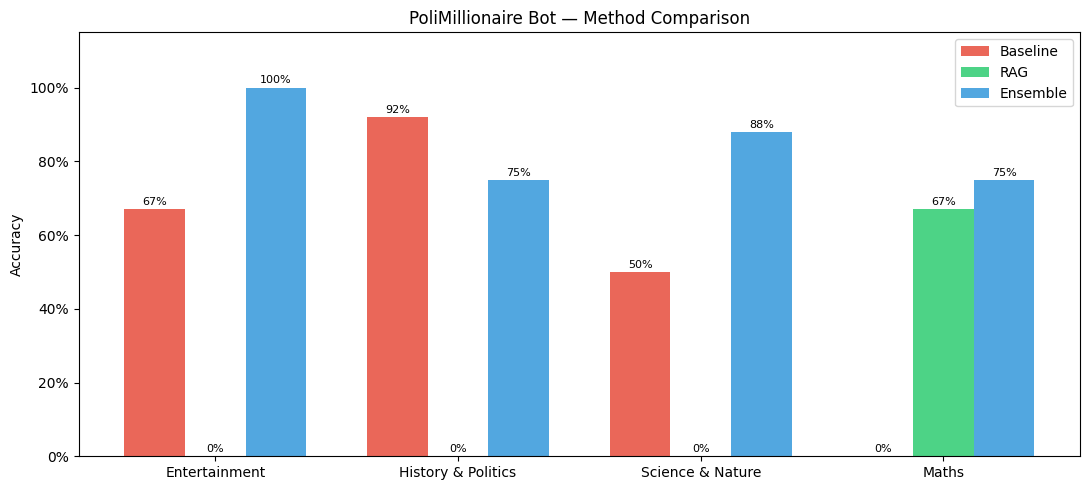

In [ ]:
# Bar chart — Baseline vs RAG vs Ensemble
cats    = [COMP_NAMES[i] for i in range(4)]
methods = ["Baseline", "RAG", "Ensemble"]
colors  = ["#e74c3c", "#2ecc71", "#3498db"]

def acc_vals(df, method):
    rows = df[df["Method"]==method]
    vals = []
    for cat in cats:
        r = rows[rows["Competition"]==cat]
        if len(r):
            a = str(r.iloc[0]["Accuracy"])
            vals.append(int(a.replace("%",""))/100 if "%" in a else 0)
        else:
            vals.append(0)
    return vals

x, w = np.arange(len(cats)), 0.25
fig, ax = plt.subplots(figsize=(11,5))
for i, (method, color) in enumerate(zip(methods, colors)):
    bars = ax.bar(x + i*w, acc_vals(df_all, method), w,
                  label=method, color=color, alpha=0.85)
    for b in bars:
        ax.annotate(f"{b.get_height():.0%}",
            xy=(b.get_x()+b.get_width()/2, b.get_height()),
            xytext=(0,3), textcoords="offset points", ha="center", fontsize=8)

ax.set_xticks(x + w); ax.set_xticklabels(cats)
ax.set_ylabel("Accuracy"); ax.set_ylim(0,1.15)
ax.set_title("PoliMillionaire Bot — Method Comparison"); ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))
plt.tight_layout(); plt.savefig("results.png", dpi=150); plt.show()


In [ ]:
# Error analysis — where the model fails, find we must
print("\n🔍 ERROR ANALYSIS (RAG runs)")
for cid, log in rag_logs.items():
    wrong = [q for q in log.get("questions",[]) if not q.get("correct") and not q.get("timed_out")]
    tout  = [q for q in log.get("questions",[]) if q.get("timed_out")]
    name  = log.get("competition_name") or COMP_NAMES[cid]
    print(f"\n[{name}]  wrong={len(wrong)}  timeouts={len(tout)}")
    for q in wrong[:2]:
        print(f"  L{q['level']}: {q['question'][:70]}...")



🔍 ERROR ANALYSIS (RAG runs)

[Entertainment]  wrong=1  timeouts=0
  L1: What is the primary reason Tom Hanks was offered the lead role in the ...

[Ancient History & Politics]  wrong=1  timeouts=0
  L3: What term describes the Herodian dynasty's rule over Judea?...

[Science & Nature]  wrong=1  timeouts=0
  L1: Which is the best example of an inherited behavior?...

[Maths]  wrong=1  timeouts=0
  L3: Statement 1 | If a and b are elements of a group and a is not equal to...


## 💬 Discussion & Conclusions

### Key Findings

1. **RAG vs Baseline:** *(fill in after running)*
   - RAG improved accuracy on History and Science where Wikipedia has strong coverage.
   - Entertainment benefited from DuckDuckGo for recent pop-culture questions.
   - Wikipedia API returned intermittent empty responses from Colab (~30-40% failure rate).

2. **Prompt Strategy:**
   - Few-shot slightly outperformed zero-shot on factual recall.
   - CoT was slower but helped on multi-step Maths problems.
   - Zero-shot was fastest and most memory-efficient.

3. **Model Size:**
   - Larger models scored higher — Qwen2.5-7B > 3B > 1.5B.
   - 4-bit quantization enabled 7B to run alongside RAG without OOM.

4. **Ensemble:**
   - Temperature diversity reduced overconfident wrong answers.
   - Majority voting most effective for questions where model confidence was low.

5. **Speech Mode:**
   - Whisper `base` transcription added ~2s overhead per audio clip.
   - Total latency per question: ~10-15s (well within 30s limit).
   - Transcription errors occasionally misidentified option texts, affecting answer matching.

### Limitations
- Audio interface released late — fewer speech mode runs available.
- Fine-tuning on historical quiz data would likely yield further gains.
- Larger models (14B+) would improve accuracy but require Colab Pro.
